In [1]:
import pickle
import pybamm
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import math
import dfols
import signal
from scipy.integrate import solve_ivp
from scipy.fft import fft, fftfreq, fftshift
from scipy.signal import savgol_filter
from scipy.signal import find_peaks
from scipy import interpolate, integrate
from stopit import threading_timeoutable as timeoutable
import matplotlib as mpl

import os, sys
sys.path.append(os.path.dirname(os.path.dirname(os.path.abspath("__file__"))))
from batfuns import *
plt.rcParams = set_rc_params(plt.rcParams)
import winsound

eSOH_DIR = "../data/esoh_R/"
oCV_DIR = "../data/ocv/"
cyc_DIR = "../data/cycling/"
fig_DIR = "../figures/figures_paper/"
res_DIR = "../data/results_paper/"
resistance_DIR = "../data/resistance/"
%matplotlib widget

In [57]:
i = 3
cell = 3*i
cell_no = f"{cell:02d}"
df1 = pd.read_csv(oCV_DIR+"ocv_data_cell_"+cell_no+".csv")

Text(0, 0.5, 'Expansion [$\\mu$m]')

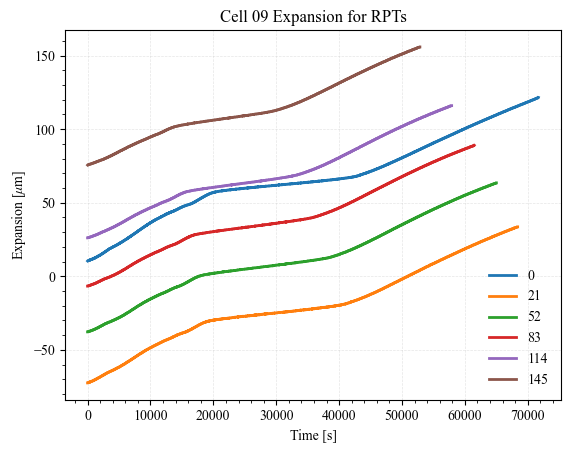

In [61]:
N = df1["N"].unique()
E = []
fig,ax=plt.subplots(1,1)
for n in N:
    df2 = df1[df1["N"] == n]
    E.append(df2["E"].min())
    ax.plot(df2["t"],df2["E"])
    ax.legend(N)
ax.set_title(f"Cell {cell_no} Expansion for RPTs")
ax.set_xlabel("Time [s]")
ax.set_ylabel(r"Expansion [$\mu$m]")

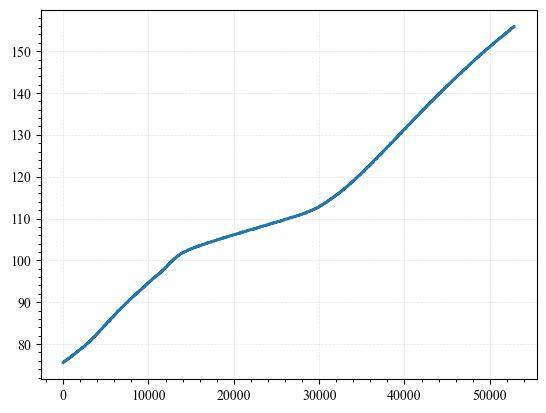

In [59]:
fig,ax=plt.subplots(1,1)
# ax.plot(N,E,"x-")
ax.plot(df2["t"],df2["E"])
